In [1]:
import pandas as pd
import os

PROJECT_ROOT = "D:/Study/HK6/Social Network/Project/code"

os.chdir(PROJECT_ROOT)

communities = pd.read_csv("outputs/communities/community_labels.csv")
nodes = pd.read_csv("data/graph/nodes.csv")
cleaned = pd.read_csv("data/processed/RC_2026-01_data.csv")

In [2]:
df = communities.merge(nodes, left_on="node", right_on="id")

df = df.merge(
    cleaned[["author_fullname", "subreddit"]],
    left_on="user",
    right_on="author_fullname"
)

df.head()

,node,leiden,louvain,user,id,author_fullname,subreddit
0,0,14,0,t2_2zycdjvn,0,t2_2zycdjvn,deadbydaylight
1,0,14,0,t2_2zycdjvn,0,t2_2zycdjvn,deadbydaylight
2,0,14,0,t2_2zycdjvn,0,t2_2zycdjvn,deadbydaylight
3,0,14,0,t2_2zycdjvn,0,t2_2zycdjvn,deadbydaylight
4,0,14,0,t2_2zycdjvn,0,t2_2zycdjvn,deadbydaylight


In [5]:
def build_interaction_dataset(df, community_col="leiden"):
    
    # Each row = 1 interaction
    data = (
        df.groupby([community_col, "subreddit"])
        .size()
        .reset_index(name="interaction_count")
    )

    # Total interactions per community
    total = (
        data.groupby(community_col)["interaction_count"]
        .sum()
        .reset_index(name="total_interactions")
    )

    # Merge
    data = data.merge(total, on=community_col)

    # Percentage
    data["percentage"] = (
        data["interaction_count"] / data["total_interactions"] * 100
    )

    return data

In [6]:
leiden_data = build_interaction_dataset(df, "leiden")
leiden_data.head()

,leiden,subreddit,interaction_count,total_interactions,percentage
0,0,2007scape,922,393654,0.234216
1,0,BaldursGate3,2381,393654,0.604846
2,0,Battlefield,2935,393654,0.745579
3,0,Brawlstars,98,393654,0.024895
4,0,ClashRoyale,202,393654,0.051314


In [7]:
leiden_data.to_csv(
    "outputs/communities/leiden_interaction_distribution.csv",
    index=False
)

In [8]:
def compute_community_sizes(df, community_col="leiden"):
    
    sizes = (
        df.groupby(community_col)["user"]
        .nunique()
        .reset_index(name="num_users")
    )

    sizes = sizes.sort_values("num_users", ascending=False)

    return sizes

In [9]:
community_sizes = compute_community_sizes(df, "leiden")
community_sizes.head(15)

,leiden,num_users
0,0,39766
1,1,16421
2,2,15877
3,3,15795
4,4,13915
5,5,13853
6,6,13747
7,7,12550
8,8,12240
9,9,12019


In [10]:
community_sizes.to_csv(
    "outputs/communities/leiden_community_sizes.csv",
    index=False
)

In [11]:
top_15_comms = community_sizes.head(15)["leiden"].tolist()

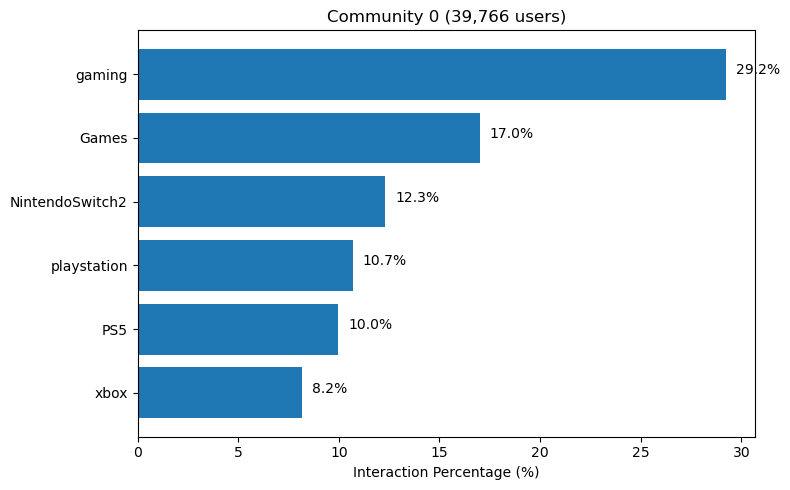

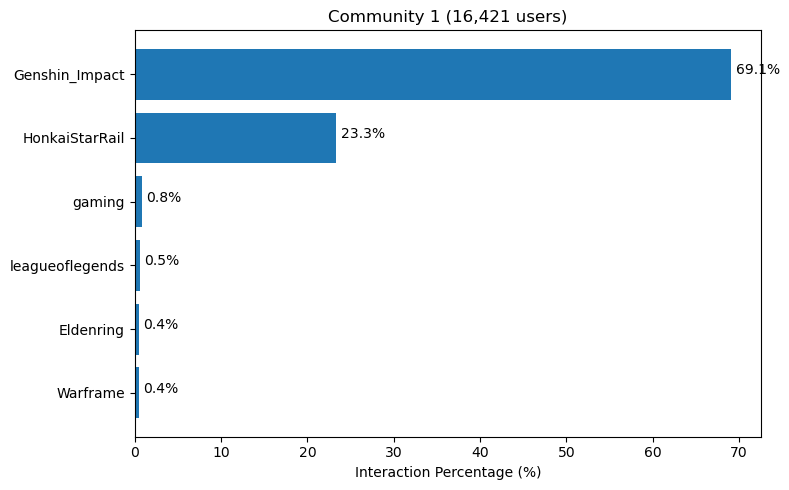

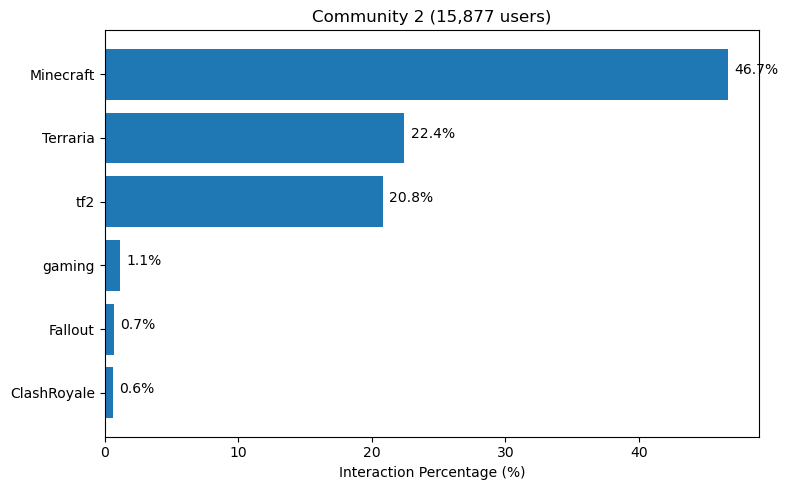

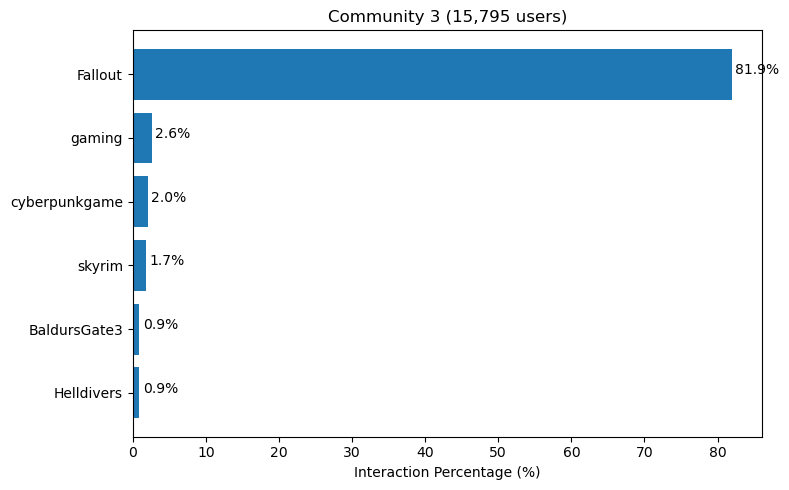

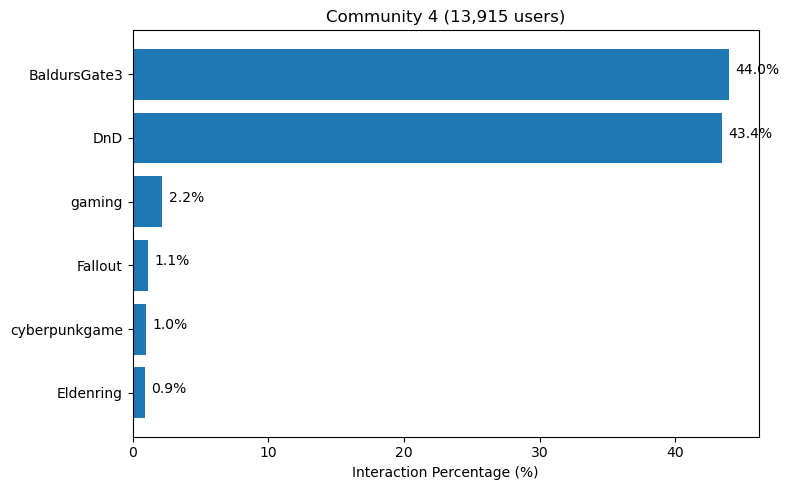

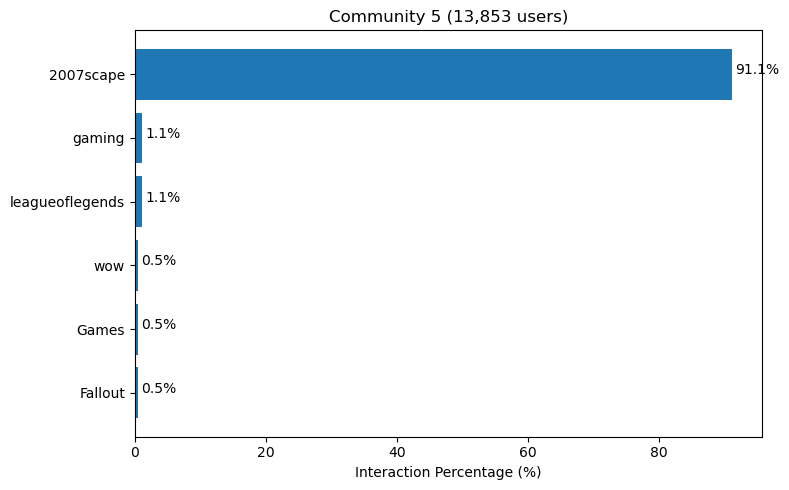

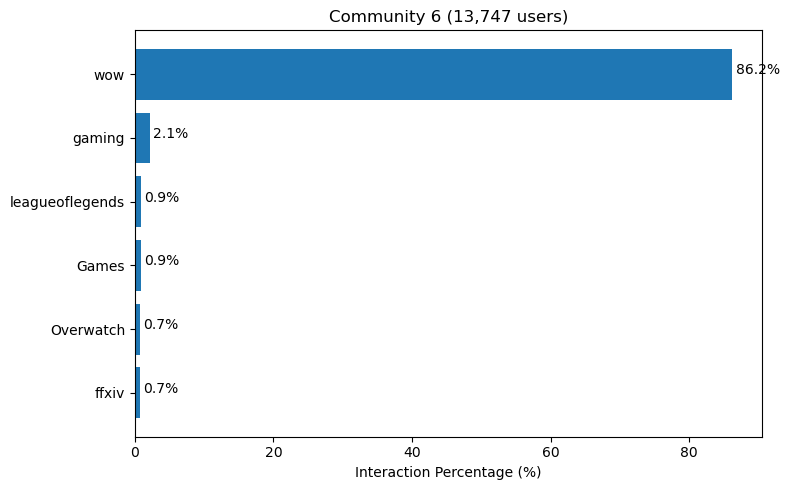

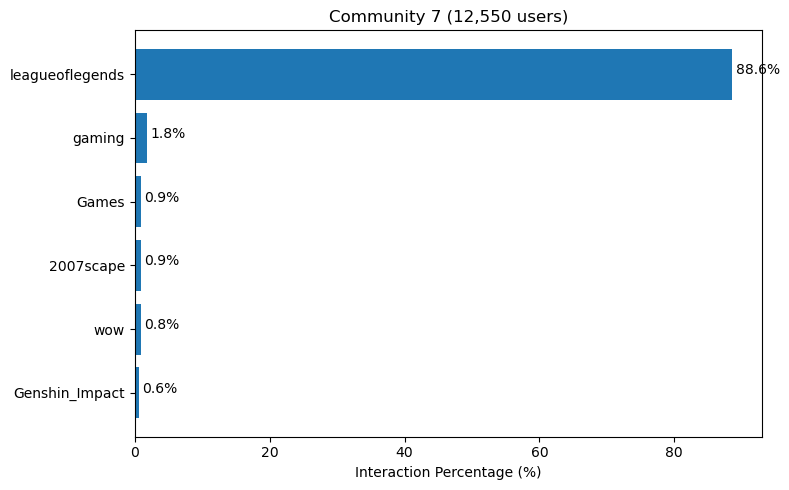

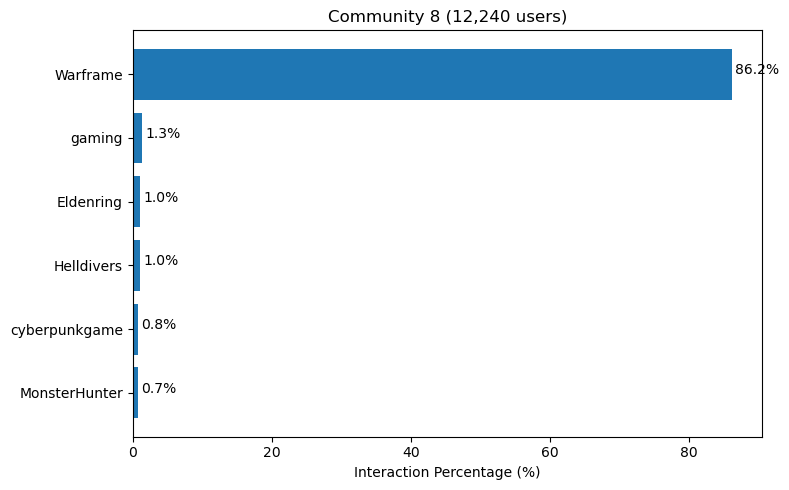

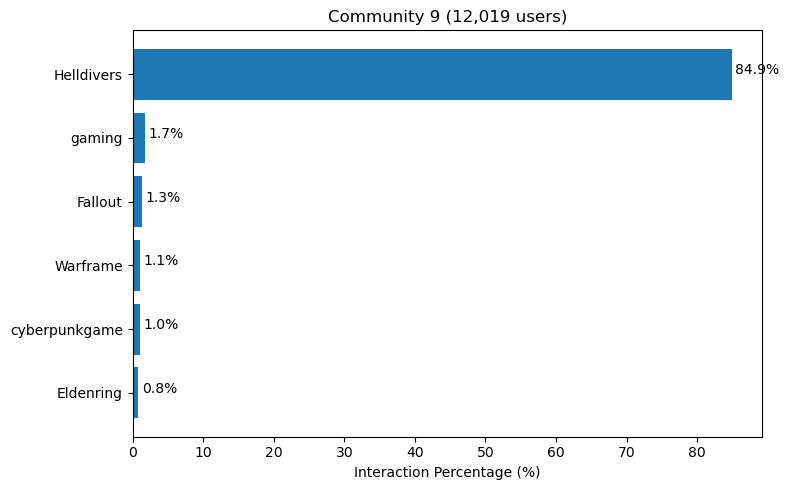

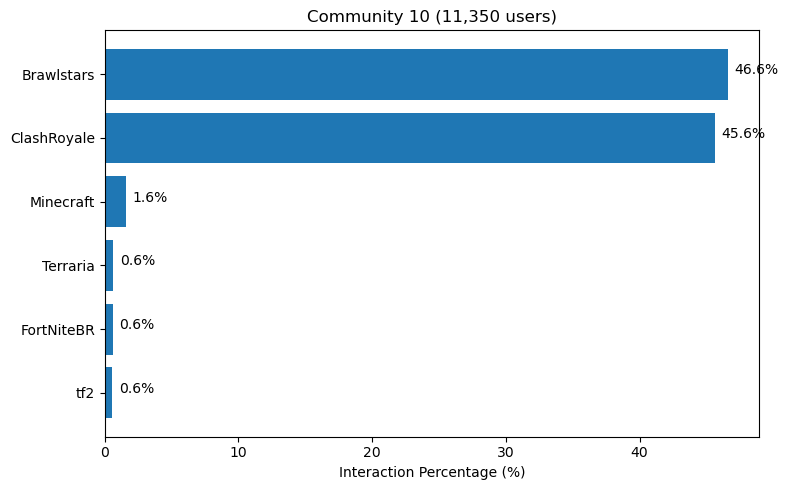

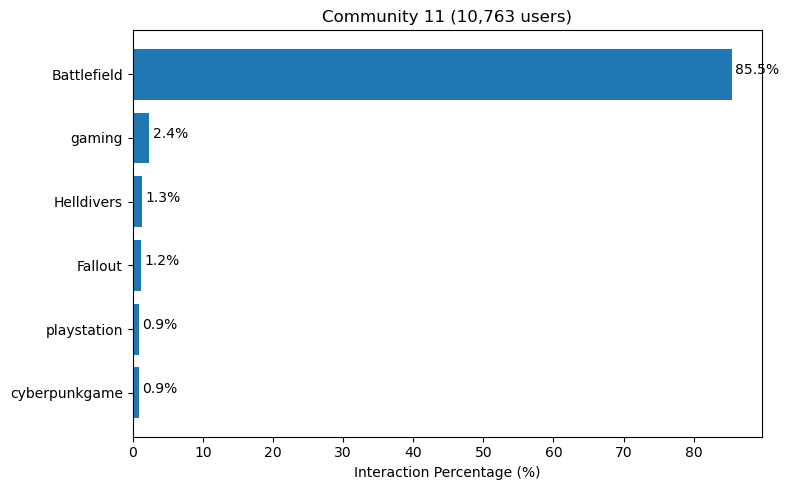

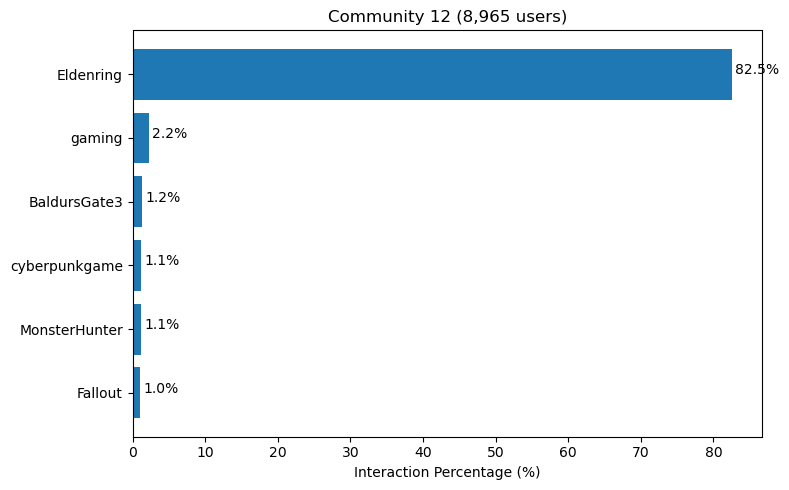

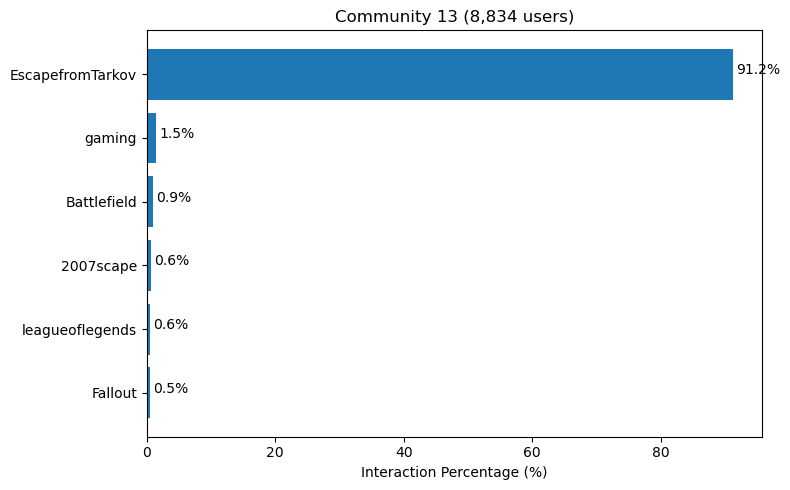

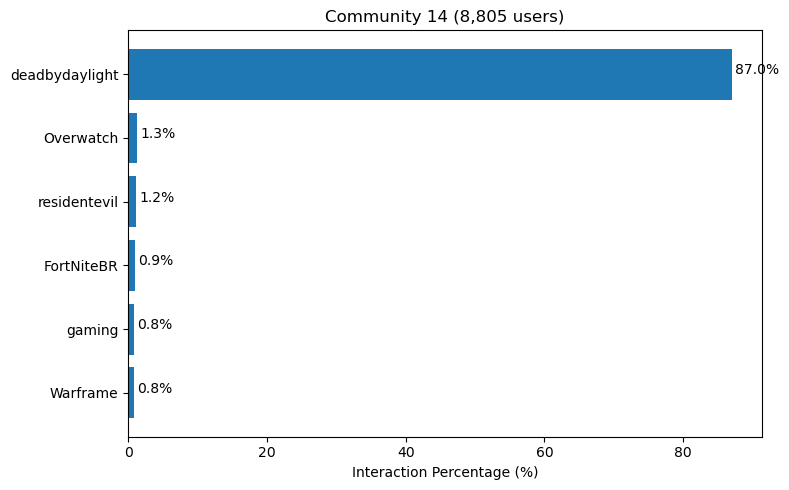

In [13]:
import matplotlib.pyplot as plt

def plot_top_subreddits_bar(data, community_id, sizes_df, community_col="leiden", top_n=6):
    
    subset = data[data[community_col] == community_id]
    subset = subset.sort_values("percentage", ascending=False).head(top_n)

    # Get number of users
    num_users = sizes_df[sizes_df[community_col] == community_id]["num_users"].values[0]

    plt.figure(figsize=(8,5))
    plt.barh(subset["subreddit"], subset["percentage"])
    plt.gca().invert_yaxis()

    plt.xlabel("Interaction Percentage (%)")
    plt.title(f"Community {community_id} ({num_users:,} users)")

    for i, v in enumerate(subset["percentage"]):
        plt.text(v + 0.5, i, f"{v:.1f}%")

    plt.tight_layout()
    plt.show()

for comm_id in top_15_comms:
    plot_top_subreddits_bar(leiden_data, comm_id, community_sizes)